In [1]:
import warnings
warnings.simplefilter(action='ignore')

import numpy as np
import pandas as pd

import pickle
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

from tensorflow import keras
import matplotlib


from astromcad.astromcad import *

2024-09-02 21:46:19.360847: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-02 21:46:21.357562: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-02 21:46:21.358980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-02 21:46:21.543373: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-02 21:46:21.889227: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def load(file_name):
    with open(file_name, 'rb') as f:
        return pickle.load(f)

target = load("data/BTS/target.pkl")
x_data = load("data/BTS/x_data.pkl")
host_galaxy_info = load("data/BTS/host_galaxy_info.pkl")


In [3]:
classes = list(np.unique(target))

In [4]:
anom_classes = classes
non_anom_classes = ['SN Ia', 'SN II', 'SN Ib/c']
for i in non_anom_classes:
    anom_classes.remove(i)
    
anom_classes.remove('other')
anom_classes.remove('Other')

colors = ['r', 'g', 'y', 'b', 'purple', 'orange', 'gray', 'k', 'm', 'c', 'brown', 'olive']

In [5]:
anom_classes

['Ca-rich',
 'ILRT',
 'LBV',
 'LRN',
 'SLSN-I',
 'SLSN-II',
 'SN Ia-91T',
 'SN Ia-91bg',
 'SN Ibn',
 'SN Ic-BL',
 'SN Icn',
 'TDE',
 'nova']

In [6]:
# Get number of observations for all light curves and get max number of timesteps 
lengths = []
for lc in x_data:
    lengths.append(len(lc))

ntimesteps = np.max(lengths)
print("Max timesteps is:", ntimesteps)

Max timesteps is: 146


In [7]:
# Pad for TF masking layer
for ind in range(len(x_data)):
    x_data[ind] = np.pad(x_data[ind], ((0, ntimesteps - len(x_data[ind])), (0, 0)))

In [15]:
# Split data into anomalous and normal classes and x inputs and y targets

y_data_anom = []
y_data_norm = []
x_data_norm = []
x_data_anom = []
host_gal_anom = []
host_gal = []

for i in range(len(target)):

    if (target[i] in anom_classes):
        x_data_anom.append(x_data[i])
        y_data_anom.append(target[i])
        host_gal_anom.append(host_galaxy_info[i])

    elif (target[i] in non_anom_classes):
        x_data_norm.append(x_data[i])
        y_data_norm.append(target[i])
        host_gal.append(host_galaxy_info[i])

# print(y_data_norm)

In [16]:
np.unique(y_data_norm, return_counts=True)

(array(['SN II', 'SN Ia', 'SN Ib/c'], dtype='<U7'), array([1212, 4454,  259]))

In [10]:
# One-hot Encoding

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore')

y_data_norm = enc.fit_transform(np.array(y_data_norm).reshape(-1, 1)).todense()

# y_data_norm

In [11]:
# Train-validation-test split: 80% training, 10% validation, 10% test 

X_train, X_test, host_gal_train, host_gal_test, y_train, y_test = train_test_split(x_data_norm, host_gal, y_data_norm, random_state = 45, test_size = 0.1)
X_train, X_val, host_gal_train, host_gal_val, y_train, y_val = train_test_split(X_train, host_gal_train, y_train, random_state = 45, test_size = 1/9)



In [12]:
# Get class_weights for imbalanced classes
class_weights = {i : 0 for i in range(y_train.shape[1])}

for value in y_train:
    class_weights[np.argmax(value)]+=1

print(class_weights)

for id in class_weights.keys():
    class_weights[id] = len(y_train) / class_weights[id]

print(class_weights)

# {0: 961, 1: 3569, 2: 209}

{0: 961, 1: 3569, 2: 209}
{0: 4.931321540062435, 1: 1.327822919585318, 2: 22.67464114832536}


In [13]:
# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val = np.array(X_val)
y_val = np.array(y_val)

X_test = np.array(X_test)
y_test = np.array(y_test)

x_data_anom = np.array(x_data_anom)
y_data_anom = np.array(y_data_anom)
host_gal_anom = np.array(host_gal_anom)


host_gal_train = np.array(host_gal_train)
host_gal_test = np.array(host_gal_test)
host_gal_val = np.array(host_gal_val)

y_train = np.squeeze(y_train)
y_val = np.squeeze(y_val)
y_test = np.squeeze(y_test)
y_data_anom = np.squeeze(y_data_anom)

In [14]:
ordered_class_names = ["SN II", "SN Ia", "SN Ib/c"]

In [22]:
model = keras.models.load_model("models/FinalModel.keras")
# model = keras.models.load_model("ELaSTiCC Data/models/Latent100")

def get_model(tr, from_base):
    num_classes = len(class_weights)
    n_features = 4

    input_1 = Input((ntimesteps, n_features), name='lc')  # X.shape = (Nobjects, Ntimesteps, 4) CHANGE

    masking_input1 = Masking(mask_value=0.)(input_1)

    gru1 = GRU(100, return_sequences=True, activation='tanh', trainable=tr)(masking_input1)
    gru2 = GRU(100, return_sequences=False, activation='tanh', trainable=tr)(gru1)

    dense1 = Dense(100, activation='tanh', trainable=tr)(gru2)

    input_2 = Input(shape = (2, ), name='host') # CHANGE

    dense2 = Dense(10, trainable=tr)(input_2)

    merge1 = concatenate([dense1, dense2])

    dense3 = Dense(100, activation='relu', trainable=tr)(merge1)

    # dense3 = Dense(100, activation='relu', trainable=False)(gru2)


    dense4 = Dense(100, activation='relu', name='latent', trainable=tr)(dense3)

    output = Dense(12, activation='softmax')(dense4)

    new_model = keras.Model(inputs=[input_1, input_2], outputs=output)

    # Load the weights from the old model into the new model
    if (from_base):
        new_model.set_weights(model.get_weights())


    new_output = Dense(3, activation='softmax')(dense3)
    
    new_model = Model(inputs=[input_1, input_2], outputs=new_output)
    
    return new_model
    
    

In [19]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

def get_auroc_cls(y_pred, y_true):

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    auroc_per_class = roc_auc_score(y_true_bin, y_pred, average=None)
    

    macro_auroc = roc_auc_score(y_true_bin, y_pred, average='macro')
    

    micro_auroc = roc_auc_score(y_true_bin, y_pred, average='micro')
    
    return auroc_per_class, macro_auroc, micro_auroc

In [20]:
np.unique([np.argmax(i) for i in y_data_norm], return_counts=True)

(array([0, 1, 2]), array([1212, 4454,  259]))

In [78]:
early_stopping = EarlyStopping(
                              patience=5,
                              min_delta=0.001,                               
                              monitor="val_loss",
                              restore_best_weights=True
                              )

transfer_perf = []
normal_perf = []
splits = []
for i in range(5):
    print(i)
    for train_size in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]:
        bad=True
        print(train_size)
        while bad:
            X_train, X_test, host_gal_train, host_gal_test, y_train, y_test = train_test_split(x_data_norm, host_gal, y_data_norm, train_size = train_size)
            X_train, X_val, host_gal_train, host_gal_val, y_train, y_val = train_test_split(X_train, host_gal_train, y_train, test_size = 0.1)
            y_test_single = [np.argmax(i) for i in y_test]
            # Get class_weights for imbalanced classes
            class_weights = {i : 0 for i in range(y_train.shape[1])}

            for value in y_train:
                class_weights[np.argmax(value)]+=1
            bad=False
            for id in class_weights.keys():
                if (class_weights[id] == 0):
                    bad=True
                    break
                class_weights[id] = len(y_train) / class_weights[id]
                
            

        # Convert to numpy arrays
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        X_val = np.array(X_val)
        y_val = np.array(y_val)

        X_test = np.array(X_test)
        y_test = np.array(y_test)

        x_data_anom = np.array(x_data_anom)
        y_data_anom = np.array(y_data_anom)
        host_gal_anom = np.array(host_gal_anom)


        host_gal_train = np.array(host_gal_train)
        host_gal_test = np.array(host_gal_test)
        host_gal_val = np.array(host_gal_val)

        y_train = np.squeeze(y_train)
        y_val = np.squeeze(y_val)
        y_test = np.squeeze(y_test)
        y_data_anom = np.squeeze(y_data_anom)

        

        # Transfer Learning
        model_transfer = get_model(False, True)
        model_transfer.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=['accuracy'])
        det = Custom(ntimesteps, 4, 2, 100, 3)
        det.custom_model(model_transfer, 'lc', 'latent')
        det.model.fit(x = [X_train, host_gal_train], validation_data=([X_val, host_gal_val], y_val), y = y_train, epochs=40, batch_size = 32, class_weight = class_weights, callbacks=[early_stopping])
        test_pred = det.predict(X_test, host_gal_test)
        transfer_perf.append(get_auroc_cls(test_pred, y_test_single))

        # Normal Training

        model_normal = get_model(True, False)
        model_normal.compile(loss = "categorical_crossentropy", optimizer="adam", metrics=['accuracy'])
        det = Custom(ntimesteps, 4, 2, 100, 3)
        det.custom_model(model_normal, 'lc', 'latent')
        det.model.fit(x = [X_train, host_gal_train], validation_data=([X_val, host_gal_val], y_val), y = y_train, epochs=40, batch_size = 32, class_weight = class_weights, callbacks=[early_stopping])
        test_pred = det.predict(X_test, host_gal_test)
        
        normal_perf.append(get_auroc_cls(test_pred, y_test_single))
        splits.append(train_size)

        print(i, train_size, transfer_perf[-1], normal_perf[-1])

    
    

0
100
Epoch 1/40
3/3 [==============================] - 6s 856ms/step - loss: 6.0360 - accuracy: 0.8111 - val_loss: 0.5959 - val_accuracy: 0.8000
Epoch 2/40
3/3 [==============================] - 0s 18ms/step - loss: 5.7309 - accuracy: 0.8111 - val_loss: 0.6359 - val_accuracy: 0.8000
Epoch 3/40
3/3 [==============================] - 0s 18ms/step - loss: 5.4099 - accuracy: 0.8000 - val_loss: 0.6721 - val_accuracy: 0.7000
Epoch 4/40
3/3 [==============================] - 0s 18ms/step - loss: 5.0768 - accuracy: 0.7556 - val_loss: 0.6982 - val_accuracy: 0.7000
Epoch 5/40
3/3 [==============================] - 0s 18ms/step - loss: 4.8238 - accuracy: 0.7222 - val_loss: 0.7299 - val_accuracy: 0.7000
Epoch 6/40
183/183 [==============================] - 2s 3ms/step
Epoch 1/40
3/3 [==============================] - 7s 848ms/step - loss: 3.5718 - accuracy: 0.2889 - val_loss: 0.9015 - val_accuracy: 0.8000
Epoch 2/40
3/3 [==============================] - 0s 23ms/step - loss: 3.4870 - accuracy: 0.

17/17 [==============================] - 0s 6ms/step - loss: 3.1569 - accuracy: 0.6241 - val_loss: 1.0505 - val_accuracy: 0.6333
Epoch 9/40
17/17 [==============================] - 0s 6ms/step - loss: 3.1086 - accuracy: 0.6611 - val_loss: 1.0526 - val_accuracy: 0.6333
Epoch 10/40
17/17 [==============================] - 0s 6ms/step - loss: 3.0773 - accuracy: 0.5685 - val_loss: 1.0501 - val_accuracy: 0.6333
Epoch 11/40
17/17 [==============================] - 0s 6ms/step - loss: 3.0429 - accuracy: 0.6611 - val_loss: 0.9962 - val_accuracy: 0.6833
Epoch 12/40
17/17 [==============================] - 0s 6ms/step - loss: 3.0149 - accuracy: 0.6796 - val_loss: 1.0327 - val_accuracy: 0.6167
Epoch 13/40
17/17 [==============================] - 0s 6ms/step - loss: 2.9888 - accuracy: 0.6759 - val_loss: 0.9766 - val_accuracy: 0.6667
Epoch 14/40
17/17 [==============================] - 0s 6ms/step - loss: 2.9673 - accuracy: 0.6611 - val_loss: 1.0191 - val_accuracy: 0.6167
Epoch 15/40
17/17 [=======

26/26 [==============================] - 24s 83ms/step - loss: 3.4204 - accuracy: 0.3568 - val_loss: 1.0939 - val_accuracy: 0.2111
Epoch 2/40
26/26 [==============================] - 0s 11ms/step - loss: 3.3588 - accuracy: 0.3123 - val_loss: 1.0039 - val_accuracy: 0.2222
Epoch 3/40
26/26 [==============================] - 0s 11ms/step - loss: 3.3623 - accuracy: 0.3630 - val_loss: 0.9960 - val_accuracy: 0.7667
Epoch 4/40
26/26 [==============================] - 0s 11ms/step - loss: 3.3293 - accuracy: 0.2049 - val_loss: 1.1370 - val_accuracy: 0.2000
Epoch 5/40
26/26 [==============================] - 0s 11ms/step - loss: 3.2678 - accuracy: 0.4099 - val_loss: 1.1372 - val_accuracy: 0.1111
Epoch 6/40
26/26 [==============================] - 0s 11ms/step - loss: 3.2424 - accuracy: 0.1444 - val_loss: 1.0596 - val_accuracy: 0.2667
Epoch 7/40
26/26 [==============================] - 0s 11ms/step - loss: 3.2558 - accuracy: 0.2481 - val_loss: 1.0219 - val_accuracy: 0.3889
Epoch 8/40
158/158 [===

Epoch 2/40
3/3 [==============================] - 0s 18ms/step - loss: 3.5256 - accuracy: 0.0778 - val_loss: 1.1674 - val_accuracy: 0.0000e+00
Epoch 3/40
3/3 [==============================] - 0s 18ms/step - loss: 3.3917 - accuracy: 0.0778 - val_loss: 1.1104 - val_accuracy: 0.0000e+00
Epoch 4/40
3/3 [==============================] - 0s 17ms/step - loss: 3.3078 - accuracy: 0.2000 - val_loss: 1.0898 - val_accuracy: 0.2000
Epoch 5/40
3/3 [==============================] - 0s 17ms/step - loss: 3.2865 - accuracy: 0.3889 - val_loss: 1.0936 - val_accuracy: 0.4000
Epoch 6/40
3/3 [==============================] - 0s 17ms/step - loss: 3.2789 - accuracy: 0.4556 - val_loss: 1.0920 - val_accuracy: 0.4000
Epoch 7/40
3/3 [==============================] - 0s 18ms/step - loss: 3.3026 - accuracy: 0.2778 - val_loss: 1.0857 - val_accuracy: 0.1000
Epoch 8/40
3/3 [==============================] - 0s 17ms/step - loss: 3.3032 - accuracy: 0.1667 - val_loss: 1.0891 - val_accuracy: 0.1000
Epoch 9/40
3/3 [===

17/17 [==============================] - 0s 6ms/step - loss: 2.7514 - accuracy: 0.6074 - val_loss: 0.8476 - val_accuracy: 0.5667
Epoch 32/40
17/17 [==============================] - 0s 6ms/step - loss: 2.7538 - accuracy: 0.6537 - val_loss: 0.8390 - val_accuracy: 0.7000
Epoch 33/40
17/17 [==============================] - 0s 6ms/step - loss: 2.7491 - accuracy: 0.6722 - val_loss: 0.7997 - val_accuracy: 0.7000
Epoch 34/40
17/17 [==============================] - 0s 5ms/step - loss: 2.7392 - accuracy: 0.7278 - val_loss: 0.8113 - val_accuracy: 0.6167
Epoch 35/40
17/17 [==============================] - 0s 6ms/step - loss: 2.7281 - accuracy: 0.6111 - val_loss: 0.8660 - val_accuracy: 0.5667
Epoch 36/40
17/17 [==============================] - 0s 6ms/step - loss: 2.7369 - accuracy: 0.6370 - val_loss: 0.8212 - val_accuracy: 0.6667
Epoch 37/40
17/17 [==============================] - 0s 6ms/step - loss: 2.7169 - accuracy: 0.6630 - val_loss: 0.8414 - val_accuracy: 0.6333
Epoch 38/40
167/167 [====

...

164/164 [==============================] - 2s 3ms/step
3 700 (array([0.76202826, 0.81037031, 0.80541636]), 0.7926049795835838, 0.8306330166433918) (array([0.5474339, 0.5926442, 0.5863655]), 0.5754811990217076, 0.8217493647123464)
800
Epoch 1/40
23/23 [==============================] - 6s 85ms/step - loss: 4.1518 - accuracy: 0.0556 - val_loss: 1.1790 - val_accuracy: 0.2500
Epoch 2/40
23/23 [==============================] - 0s 6ms/step - loss: 3.3176 - accuracy: 0.3611 - val_loss: 1.0765 - val_accuracy: 0.5125
Epoch 3/40
23/23 [==============================] - 0s 5ms/step - loss: 3.2888 - accuracy: 0.5597 - val_loss: 1.1110 - val_accuracy: 0.3375
Epoch 4/40
23/23 [==============================] - 0s 6ms/step - loss: 3.2207 - accuracy: 0.2583 - val_loss: 1.0656 - val_accuracy: 0.4500
Epoch 5/40
23/23 [==============================] - 0s 6ms/step - loss: 3.1724 - accuracy: 0.6139 - val_loss: 1.0404 - val_accuracy: 0.5000
Epoch 6/40
23/23 [==============================] - 0s 6ms/step -

29/29 [==============================] - 0s 5ms/step - loss: 2.9392 - accuracy: 0.6167 - val_loss: 0.9358 - val_accuracy: 0.6400
Epoch 14/40
29/29 [==============================] - 0s 6ms/step - loss: 2.9094 - accuracy: 0.6711 - val_loss: 0.9062 - val_accuracy: 0.6800
Epoch 15/40
29/29 [==============================] - 0s 6ms/step - loss: 2.9391 - accuracy: 0.5000 - val_loss: 0.8860 - val_accuracy: 0.7000
Epoch 16/40
29/29 [==============================] - 0s 5ms/step - loss: 2.8885 - accuracy: 0.6889 - val_loss: 0.8980 - val_accuracy: 0.6900
Epoch 17/40
29/29 [==============================] - 0s 5ms/step - loss: 2.8758 - accuracy: 0.6778 - val_loss: 0.9038 - val_accuracy: 0.6300
Epoch 18/40
29/29 [==============================] - 0s 5ms/step - loss: 2.8689 - accuracy: 0.6500 - val_loss: 0.9128 - val_accuracy: 0.6200
Epoch 19/40
29/29 [==============================] - 0s 5ms/step - loss: 2.8593 - accuracy: 0.6133 - val_loss: 0.8533 - val_accuracy: 0.7100
Epoch 20/40
29/29 [======

Epoch 7/40
183/183 [==============================] - 2s 3ms/step
4 100 (array([0.37029495, 0.75921947, 0.77355281]), 0.6343557408997268, 0.7317206284882758) (array([0.42598701, 0.45843137, 0.40858232]), 0.43100023495108597, 0.5685028421963934)
200
Epoch 1/40
6/6 [==============================] - 6s 340ms/step - loss: 5.2332 - accuracy: 0.2111 - val_loss: 2.7898 - val_accuracy: 0.2000
Epoch 2/40
6/6 [==============================] - 0s 10ms/step - loss: 4.6116 - accuracy: 0.2000 - val_loss: 2.3742 - val_accuracy: 0.1500
Epoch 3/40
6/6 [==============================] - 0s 10ms/step - loss: 4.0647 - accuracy: 0.1944 - val_loss: 1.9469 - val_accuracy: 0.0500
Epoch 4/40
6/6 [==============================] - 0s 9ms/step - loss: 3.6319 - accuracy: 0.1278 - val_loss: 1.5591 - val_accuracy: 0.0000e+00
Epoch 5/40
6/6 [==============================] - 0s 10ms/step - loss: 3.3349 - accuracy: 0.1389 - val_loss: 1.2502 - val_accuracy: 0.1000
Epoch 6/40
6/6 [==============================] - 0s

164/164 [==============================] - 2s 3ms/step
4 700 (array([0.74070651, 0.8012784 , 0.71122756]), 0.7510708225420067, 0.8495084086902772) (array([0.63570982, 0.72011349, 0.63889689]), 0.6649067322999435, 0.8820312721778347)
800
Epoch 1/40
23/23 [==============================] - 6s 80ms/step - loss: 4.1670 - accuracy: 0.2125 - val_loss: 1.1815 - val_accuracy: 0.1375
Epoch 2/40
23/23 [==============================] - 0s 6ms/step - loss: 3.3817 - accuracy: 0.1069 - val_loss: 1.1249 - val_accuracy: 0.0625
Epoch 3/40
23/23 [==============================] - 0s 5ms/step - loss: 3.2873 - accuracy: 0.2861 - val_loss: 1.0517 - val_accuracy: 0.4875
Epoch 4/40
23/23 [==============================] - 0s 5ms/step - loss: 3.2240 - accuracy: 0.6569 - val_loss: 1.0505 - val_accuracy: 0.4375
Epoch 5/40
23/23 [==============================] - 0s 5ms/step - loss: 3.1811 - accuracy: 0.2417 - val_loss: 0.9767 - val_accuracy: 0.6750
Epoch 6/40
23/23 [==============================] - 0s 5ms/ste

57/57 [==============================] - 0s 5ms/step - loss: 3.0338 - accuracy: 0.5811 - val_loss: 0.9241 - val_accuracy: 0.6600
Epoch 6/40
57/57 [==============================] - 0s 5ms/step - loss: 2.9901 - accuracy: 0.5317 - val_loss: 0.9080 - val_accuracy: 0.6350
Epoch 7/40
57/57 [==============================] - 0s 5ms/step - loss: 2.9401 - accuracy: 0.6106 - val_loss: 0.9000 - val_accuracy: 0.6600
Epoch 8/40
57/57 [==============================] - 0s 4ms/step - loss: 2.8849 - accuracy: 0.6133 - val_loss: 0.9816 - val_accuracy: 0.5650
Epoch 9/40
57/57 [==============================] - 0s 4ms/step - loss: 2.8851 - accuracy: 0.5817 - val_loss: 0.8554 - val_accuracy: 0.7100
Epoch 10/40
57/57 [==============================] - 0s 4ms/step - loss: 2.8551 - accuracy: 0.6061 - val_loss: 0.8574 - val_accuracy: 0.6200
Epoch 11/40
57/57 [==============================] - 0s 4ms/step - loss: 2.8352 - accuracy: 0.5939 - val_loss: 0.8158 - val_accuracy: 0.7500
Epoch 12/40
57/57 [==========

In [80]:
vals = zip(splits, transfer_perf, normal_perf)

norm_perf = {}
trans_perf = {}
for i in vals:
    if (i[0] not in norm_perf):
        norm_perf[i[0]]=[]
        trans_perf[i[0]]=[]
    norm_perf[i[0]].append(i[2][1])
    trans_perf[i[0]].append(i[1][1])    

In [81]:
norm_dev = {}
trans_dev = {}
for i in norm_perf.keys():
    norm_dev[i]=np.median(np.abs(norm_perf[i] - np.median(norm_perf[i])))
    trans_dev[i]=np.median(np.abs(trans_perf[i] - np.median(trans_perf[i])))
    norm_perf[i]=np.median(norm_perf[i])
    trans_perf[i]=np.median(trans_perf[i])
    

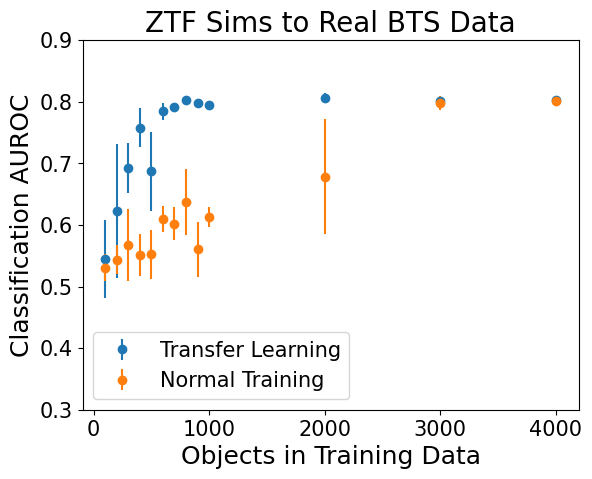

In [83]:
def saveplot(savepath): # Saves a plot (called in like every function)
    if (savepath):
        if ("UMAP" not in savepath):
            plt.savefig(savepath + '.pdf', bbox_inches='tight')
        else:
            plt.savefig(savepath + '.png', bbox_inches='tight')
            
            
def save(obj, filename):
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)

fig, ax= plt.subplots()
ax.errorbar(trans_perf.keys(), trans_perf.values(), yerr=list(trans_dev.values()), label='Transfer Learning', marker='o', linestyle='None')

ax.errorbar(norm_perf.keys(), norm_perf.values(), yerr=list(norm_dev.values()), label='Normal Training', marker='o', linestyle='None')
ax.set_xlabel('Objects in Training Data', fontsize=18)
ax.set_ylabel('Classification AUROC', fontsize=18)
ax.legend(fontsize=15)
ax.set_title('ZTF Sims to Real BTS Data', fontsize=20)

plt.ylim(0.3, 0.9)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

saveplot('transfer/ZTFtoBTSGranular')